# Implementasi Knowledge Graph Attention Network (KGAT) untuk Sistem Rekomendasi Film pada Dataset HetRec

## Setup

In [1]:
import os, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

DATA_DIR = './data'

MIN_USER_RATINGS = 20
MIN_ITEM_RATINGS = 5
RATING_THRESHOLD = 3.5
TRAIN_RATIO      = 0.8
VAL_RATIO        = 0.1

EMBED_DIM    = 64
N_LAYERS     = 3
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-5
REG_WEIGHT   = 1e-4
BATCH_SIZE   = 1024
MAX_EPOCH    = 100
PATIENCE     = 10
K_LIST       = [5, 10, 20]
TRANSR_EPOCHS = 100

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.11.0+cu128


## 1. Load Data

In [2]:
def load_dat(fn, sep='\t', enc='latin-1', **kw):
    path = os.path.join(DATA_DIR, fn)
    try:
        df = pd.read_csv(path, sep=sep, encoding=enc, **kw)
        print(f'  OK  {fn:<42} {df.shape}')
        return df
    except FileNotFoundError:
        print(f'  !! {fn} TIDAK DITEMUKAN')
        return None

df_ratings    = load_dat('user_ratedmovies.dat')
df_ratings_ts = load_dat('user_ratedmovies-timestamps.dat')
df_movies     = load_dat('movies.dat')
df_actors     = load_dat('movie_actors.dat')
df_directors  = load_dat('movie_directors.dat')
df_genres     = load_dat('movie_genres.dat')
df_countries  = load_dat('movie_countries.dat')
df_movie_tags = load_dat('movie_tags.dat')

print('\nPreview ratings:')
display(df_ratings.head())

  OK  user_ratedmovies.dat                       (855598, 9)
  OK  user_ratedmovies-timestamps.dat            (855598, 4)
  OK  movies.dat                                 (10197, 21)
  OK  movie_actors.dat                           (231742, 4)
  OK  movie_directors.dat                        (10155, 3)
  OK  movie_genres.dat                           (20809, 2)
  OK  movie_countries.dat                        (10197, 2)
  OK  movie_tags.dat                             (51795, 3)

Preview ratings:


,userID,movieID,rating,date_day,date_month,date_year,date_hour,date_minute,date_second
0,75,3,1.0,29,10,2006,23,17,16
1,75,32,4.5,29,10,2006,23,23,44
2,75,110,4.0,29,10,2006,23,30,8
3,75,160,2.0,29,10,2006,23,16,52
4,75,163,4.0,29,10,2006,23,29,30


## 2. Exploratory Data Analysis (EDA)

In [3]:
rating_col = 'rating' if 'rating' in df_ratings.columns else df_ratings.columns[2]
genre_col  = 'genre'  if 'genre'  in df_genres.columns  else df_genres.columns[1]

n_users  = df_ratings['userID'].nunique()
n_films  = df_ratings['movieID'].nunique()
n_inter  = len(df_ratings)
sparsity = 1 - n_inter / (n_users * n_films)

print(f'User           : {n_users:,}')
print(f'Film           : {n_films:,}')
print(f'Rating         : {n_inter:,}')
print(f'Genre unik     : {df_genres[genre_col].nunique()}')
print(f'Director unik  : {df_directors.iloc[:,1].nunique():,}')
print(f'Actor unik     : {df_actors.iloc[:,1].nunique():,}')
print(f'Sparsity       : {sparsity:.4%}')
print(f'Avg rating/user: {n_inter/n_users:.1f}')

print('\nMissing values per dataframe:')
for name, df in [('ratings', df_ratings), ('movies', df_movies),
                 ('actors', df_actors), ('directors', df_directors),
                 ('genres', df_genres), ('countries', df_countries)]:
    if df is not None:
        m = df.isnull().sum().sum()
        print(f'  {name:<12}: {m} missing')

User           : 2,113
Film           : 10,109
Rating         : 855,598
Genre unik     : 20
Director unik  : 4,060
Actor unik     : 95,321
Sparsity       : 95.9945%
Avg rating/user: 404.9

Missing values per dataframe:
  ratings     : 0 missing
  movies      : 492 missing
  actors      : 5 missing
  directors   : 0 missing
  genres      : 0 missing
  countries   : 8 missing


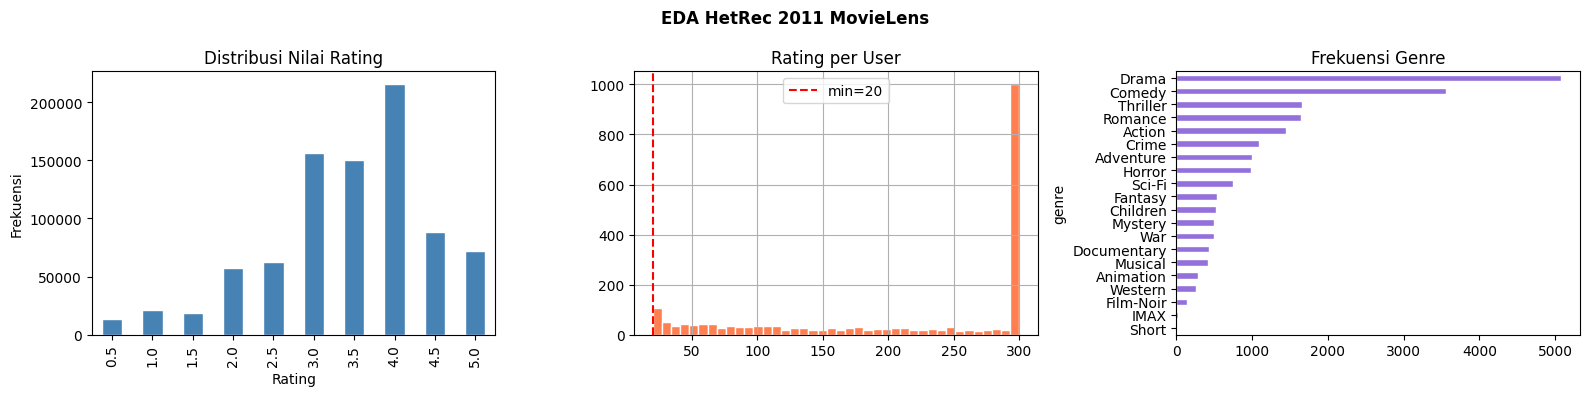

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA HetRec 2011 MovieLens', fontweight='bold')

df_ratings[rating_col].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Nilai Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frekuensi')

rpu = df_ratings.groupby('userID').size()
rpu.clip(upper=300).hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(MIN_USER_RATINGS, color='red', linestyle='--',
                label=f'min={MIN_USER_RATINGS}')
axes[1].set_title('Rating per User')
axes[1].legend()

df_genres[genre_col].value_counts().plot(
    kind='barh', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('Frekuensi Genre')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [5]:
before = {name: len(df) for name, df in [('actors', df_actors), ('movies', df_movies), ('countries', df_countries)] if df is not None}
df_movies   = df_movies.dropna().reset_index(drop=True)
df_actors    = df_actors.dropna().reset_index(drop=True)
df_countries = df_countries.dropna().reset_index(drop=True)
after = {name: len(df) for name, df in [('movies', df_movies), ('actors', df_actors), ('countries', df_countries)]}

print('Drop NaN:')
for name in after:
    dropped = before[name] - after[name]
    print(f'  {name:<12}: {before[name]:>7,} -> {after[name]:>7,}  (hapus {dropped:,})')

Drop NaN:
  movies      :  10,197 ->   9,730  (hapus 467)
  actors      : 231,742 -> 231,737  (hapus 5)
  countries   :  10,197 ->  10,189  (hapus 8)


In [6]:
# Filter cold-start secara iteratif
df_f = df_ratings.copy()
prev, it = None, 0
while prev != df_f.shape:
    prev = df_f.shape
    it += 1
    uc = df_f.groupby('userID').size()
    df_f = df_f[df_f['userID'].isin(uc[uc >= MIN_USER_RATINGS].index)]
    ic = df_f.groupby('movieID').size()
    df_f = df_f[df_f['movieID'].isin(ic[ic >= MIN_ITEM_RATINGS].index)]

print(f'Filter selesai : {df_ratings.shape} -> {df_f.shape}')
print(f'User: {df_f["userID"].nunique():,} | Film: {df_f["movieID"].nunique():,}')

# Binarisasi — ambil hanya interaksi positif
df_pos = df_f[df_f[rating_col] >= RATING_THRESHOLD].copy()
df_pos['label'] = 1
print(f'Interaksi positif: {len(df_pos):,} ({len(df_pos)/len(df_f)*100:.1f}%)')

Filter selesai : (855598, 9) -> (850955, 9)
User: 2,111 | Film: 8,155
Interaksi positif: 524,567 (61.6%)


In [7]:
# Encode semua entity ke integer
valid_users  = df_pos['userID'].unique()
valid_movies = df_pos['movieID'].unique()

user_map  = {u: i for i, u in enumerate(sorted(valid_users))}
movie_map = {m: i for i, m in enumerate(sorted(valid_movies))}

# Filter metadata ke film yang valid
mc_g = df_genres.columns[0]
genre_col2 = 'genre' if 'genre' in df_genres.columns else df_genres.columns[1]
df_genres_f    = df_genres[df_genres[mc_g].isin(valid_movies)].copy()

mc_d = df_directors.columns[0]
director_col = df_directors.columns[1]
df_directors_f = df_directors[df_directors[mc_d].isin(valid_movies)].copy()
df_directors_f[director_col] = df_directors_f[director_col].astype(str)

mc_c = df_countries.columns[0]
country_col = df_countries.columns[1]
df_countries_f = df_countries[df_countries[mc_c].isin(valid_movies)].copy()
df_countries_f[country_col] = df_countries_f[country_col].astype(str)

mc_a = df_actors.columns[0]
actor_col = df_actors.columns[1]
df_actors_f = df_actors[df_actors[mc_a].isin(valid_movies)].copy()
df_actors_f[actor_col] = df_actors_f[actor_col].astype(str)
if 'ranking' in df_actors_f.columns:
    df_actors_f = df_actors_f[df_actors_f['ranking'] <= 3]
    print(f'Aktor setelah filter top-3/film: {len(df_actors_f):,}')

df_movie_tags_f = pd.DataFrame()
if df_movie_tags is not None:
    mt_movie_col = df_movie_tags.columns[0]
    mt_tag_col   = df_movie_tags.columns[1]
    df_movie_tags_f = df_movie_tags[df_movie_tags[mt_movie_col].isin(valid_movies)].copy()

# Buat mapping entity
genre_map    = {g: i for i, g in enumerate(sorted(df_genres_f[genre_col2].unique()))}
director_map = {d: i for i, d in enumerate(sorted(df_directors_f[director_col].unique()))}
actor_map    = {a: i for i, a in enumerate(sorted(df_actors_f[actor_col].unique()))}
country_map  = {c: i for i, c in enumerate(sorted(df_countries_f[country_col].unique()))}
tag_map      = ({t: i for i, t in enumerate(sorted(df_movie_tags_f[mt_tag_col].unique()))}
               if not df_movie_tags_f.empty else {})

for name, m in [('User', user_map), ('Movie', movie_map), ('Genre', genre_map),
                ('Director', director_map), ('Actor', actor_map),
                ('Tag', tag_map), ('Country', country_map)]:
    print(f'  {name:<10}: {len(m):,}')

Aktor setelah filter top-3/film: 25,953
  User      : 2,110
  Movie     : 8,006
  Genre     : 19
  Director  : 3,155
  Actor     : 10,765
  Tag       : 5,292
  Country   : 63


In [8]:
# Train / Val / Test
ts_col = 'timestamp' if 'timestamp' in df_ratings_ts.columns else df_ratings_ts.columns[-1]
df_pos_ts = df_pos.merge(
    df_ratings_ts[['userID', 'movieID', ts_col]].rename(columns={ts_col: 'timestamp'}),
    on=['userID', 'movieID'], how='left')
df_pos_ts['timestamp'] = df_pos_ts['timestamp'].fillna(0).astype(int)
df_pos_ts = df_pos_ts.sort_values(['userID', 'timestamp'])

train_list, val_list, test_list = [], [], []
skipped = 0
for uid, grp in df_pos_ts.groupby('userID'):
    n = len(grp)
    if n < 5:
        train_list.append(grp)
        skipped += 1
        continue
    n_tr = max(1, int(np.floor(n * TRAIN_RATIO)))
    n_va = max(1, int(np.floor(n * VAL_RATIO)))
    train_list.append(grp.iloc[:n_tr])
    val_list.append(grp.iloc[n_tr:n_tr + n_va])
    test_list.append(grp.iloc[n_tr + n_va:])

df_train = pd.concat(train_list).reset_index(drop=True)
df_val   = pd.concat(val_list).reset_index(drop=True)  if val_list  else pd.DataFrame()
df_test  = pd.concat(test_list).reset_index(drop=True) if test_list else pd.DataFrame()

total = len(df_train) + len(df_val) + len(df_test)
print(f'Train  : {len(df_train):,}  ({len(df_train)/total*100:.1f}%)')
print(f'Val    : {len(df_val):,}  ({len(df_val)/total*100:.1f}%)')
print(f'Test   : {len(df_test):,}  ({len(df_test)/total*100:.1f}%)')
print(f'Skip cold-start: {skipped} user')

Train  : 418,800  (79.8%)
Val    : 51,514  (9.8%)
Test   : 54,253  (10.3%)
Skip cold-start: 5 user


## 4. Knowledge Graph Construction

In [9]:
N_USER, N_MOVIE   = len(user_map), len(movie_map)
N_GENRE, N_DIR    = len(genre_map), len(director_map)
N_ACTOR, N_TAG    = len(actor_map), len(tag_map)
N_COUNTRY         = len(country_map)

OFFSET_USER    = 0
OFFSET_MOVIE   = OFFSET_USER    + N_USER
OFFSET_GENRE   = OFFSET_MOVIE   + N_MOVIE
OFFSET_DIR     = OFFSET_GENRE   + N_GENRE
OFFSET_ACTOR   = OFFSET_DIR     + N_DIR
OFFSET_TAG     = OFFSET_ACTOR   + N_ACTOR
OFFSET_COUNTRY = OFFSET_TAG     + N_TAG
N_ENTITY       = OFFSET_COUNTRY + N_COUNTRY

REL = {'rates': 0, 'has_genre': 1, 'directed_by': 2,
       'acted_in': 3, 'has_tag': 4, 'produced_in': 5}
N_REL_BASE  = len(REL)
N_REL_TOTAL = N_REL_BASE * 2

for name, off, n in [
    ('USER',    OFFSET_USER,    N_USER),
    ('MOVIE',   OFFSET_MOVIE,   N_MOVIE),
    ('GENRE',   OFFSET_GENRE,   N_GENRE),
    ('DIR',     OFFSET_DIR,     N_DIR),
    ('ACTOR',   OFFSET_ACTOR,   N_ACTOR),
    ('TAG',     OFFSET_TAG,     N_TAG),
    ('COUNTRY', OFFSET_COUNTRY, N_COUNTRY),
]:
    print(f'  {name:<10} [{off:>6} – {off+n-1:>6}]  ({n:,} node)')
print(f'  TOTAL ENTITY : {N_ENTITY:,}')
print(f'  TOTAL RELASI : {N_REL_TOTAL}')

  USER       [     0 –   2109]  (2,110 node)
  MOVIE      [  2110 –  10115]  (8,006 node)
  GENRE      [ 10116 –  10134]  (19 node)
  DIR        [ 10135 –  13289]  (3,155 node)
  ACTOR      [ 13290 –  24054]  (10,765 node)
  TAG        [ 24055 –  29346]  (5,292 node)
  COUNTRY    [ 29347 –  29409]  (63 node)
  TOTAL ENTITY : 29,410
  TOTAL RELASI : 12


In [10]:
all_h, all_r, all_t = [], [], []

def add_triplets(h_arr, rel_id, t_arr):
    h = h_arr.tolist()
    t = t_arr.tolist()
    n = len(h)
    all_h.extend(h)
    all_r.extend([rel_id] * n)
    all_t.extend(t)
    all_h.extend(t)
    all_r.extend([rel_id + N_REL_BASE] * n)
    all_t.extend(h)

# rates
dr = df_train[df_train['userID'].isin(user_map) & df_train['movieID'].isin(movie_map)]
add_triplets(
    dr['userID'].map(user_map).values  + OFFSET_USER,
    REL['rates'],
    dr['movieID'].map(movie_map).values + OFFSET_MOVIE)
print(f'[rates]       {len(dr):>8,}')

# has_genre
dg = df_genres_f[df_genres_f[mc_g].isin(movie_map) & df_genres_f[genre_col2].isin(genre_map)]
add_triplets(
    dg[mc_g].map(movie_map).values         + OFFSET_MOVIE,
    REL['has_genre'],
    dg[genre_col2].map(genre_map).values   + OFFSET_GENRE)
print(f'[has_genre]   {len(dg):>8,}')

# directed_by
dd = df_directors_f[df_directors_f[mc_d].isin(movie_map) & df_directors_f[director_col].isin(director_map)]
add_triplets(
    dd[mc_d].map(movie_map).values             + OFFSET_MOVIE,
    REL['directed_by'],
    dd[director_col].map(director_map).values  + OFFSET_DIR)
print(f'[directed_by] {len(dd):>8,}')

# acted_in
da = df_actors_f[df_actors_f[mc_a].isin(movie_map) & df_actors_f[actor_col].isin(actor_map)]
add_triplets(
    da[mc_a].map(movie_map).values         + OFFSET_MOVIE,
    REL['acted_in'],
    da[actor_col].map(actor_map).values    + OFFSET_ACTOR)
print(f'[acted_in]    {len(da):>8,}')

# has_tag
if not df_movie_tags_f.empty and tag_map:
    dm = df_movie_tags_f[df_movie_tags_f[mt_movie_col].isin(movie_map) &
                         df_movie_tags_f[mt_tag_col].isin(tag_map)]
    add_triplets(
        dm[mt_movie_col].map(movie_map).values + OFFSET_MOVIE,
        REL['has_tag'],
        dm[mt_tag_col].map(tag_map).values     + OFFSET_TAG)
    print(f'[has_tag]     {len(dm):>8,}')
else:
    print('[has_tag]     tidak tersedia')

# produced_in
dc = df_countries_f[df_countries_f[mc_c].isin(movie_map) & df_countries_f[country_col].isin(country_map)]
add_triplets(
    dc[mc_c].map(movie_map).values             + OFFSET_MOVIE,
    REL['produced_in'],
    dc[country_col].map(country_map).values    + OFFSET_COUNTRY)
print(f'[produced_in] {len(dc):>8,}')

# Deduplikasi
triplets    = list(set(zip(all_h, all_r, all_t)))
df_triplets = pd.DataFrame(triplets, columns=['head', 'relation', 'tail'])
print(f'\nTotal tripel unik: {len(triplets):,}')

[rates]        418,800
[has_genre]     17,093
[directed_by]    7,978
[acted_in]      25,953
[has_tag]       50,277
[produced_in]    8,002

Total tripel unik: 1,056,206


## 5. Graph Structural Analysis

Node          : 29,410
Edge          : 528,103
Density       : 0.000611
Komponen      : 1  (terbesar: 29,410 node)
Avg in-degree : 17.96
Max in-degree : 5,526


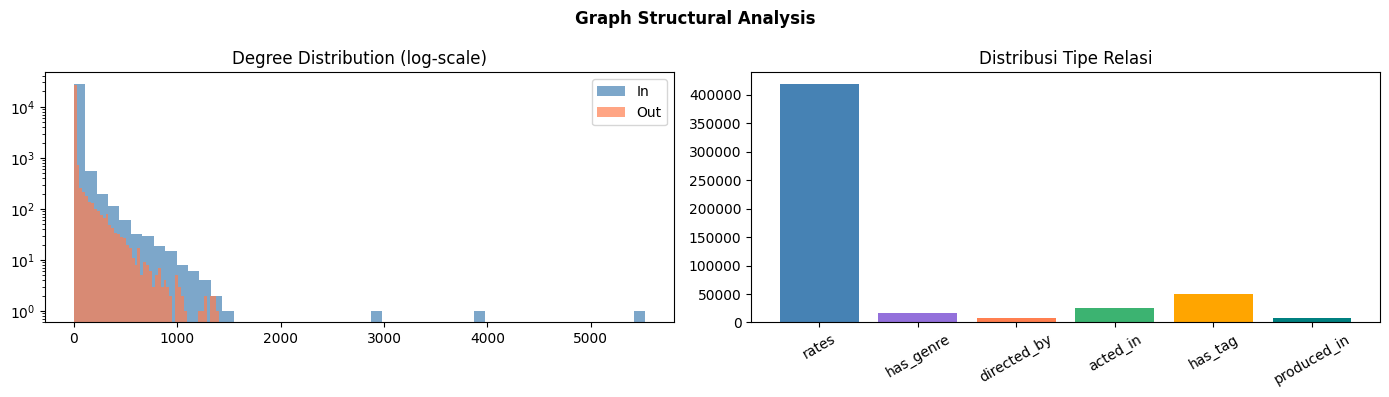

In [11]:
G = nx.DiGraph()
G.add_edges_from([(h, t, {'r': r}) for h, r, t in triplets if r < N_REL_BASE])
G_un    = G.to_undirected()
comps   = list(nx.connected_components(G_un))
in_deg  = [d for _, d in G.in_degree()]
out_deg = [d for _, d in G.out_degree()]

print(f'Node          : {G.number_of_nodes():,}')
print(f'Edge          : {G.number_of_edges():,}')
print(f'Density       : {nx.density(G):.6f}')
print(f'Komponen      : {len(comps)}  (terbesar: {len(max(comps, key=len)):,} node)')
print(f'Avg in-degree : {np.mean(in_deg):.2f}')
print(f'Max in-degree : {max(in_deg):,}')

rel_names = {v: k for k, v in REL.items()}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Graph Structural Analysis', fontweight='bold')

axes[0].hist(in_deg,  bins=50, color='steelblue', alpha=0.7, label='In',  log=True)
axes[0].hist(out_deg, bins=50, color='coral',     alpha=0.7, label='Out', log=True)
axes[0].set_title('Degree Distribution (log-scale)')
axes[0].legend()

rc = df_triplets[df_triplets['relation'] < N_REL_BASE]['relation'].value_counts().sort_index()
axes[1].bar([rel_names.get(i, str(i)) for i in rc.index], rc.values,
            color=['steelblue','mediumpurple','coral','mediumseagreen','orange','teal'][:len(rc)])
axes[1].set_title('Distribusi Tipe Relasi')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [12]:
import matplotlib.patches as mpatches

ENTITY_COLORS = {
    'User': '#7F77DD', 'Movie': '#1D9E75', 'Genre': '#D85A30',
    'Director': '#378ADD', 'Actor': '#D4537E', 'Tag': '#BA7517', 'Country': '#639922',
}

REL_COLORS = {
    'rates': '#7F77DD', 'has_genre': '#D85A30', 'directed_by': '#378ADD',
    'acted_in': '#D4537E', 'has_tag': '#BA7517', 'produced_in': '#639922',
}

def get_entity_type(node_id):
    if node_id < OFFSET_MOVIE:   return 'User'
    if node_id < OFFSET_GENRE:   return 'Movie'
    if node_id < OFFSET_DIR:     return 'Genre'
    if node_id < OFFSET_ACTOR:   return 'Director'
    if node_id < OFFSET_TAG:     return 'Actor'
    if node_id < OFFSET_COUNTRY: return 'Tag'
    return 'Country'

center = OFFSET_MOVIE
by_type = defaultdict(list)
for h, r, t in triplets:
    if r >= N_REL_BASE: continue
    if h == center: by_type[get_entity_type(t)].append(t)
    elif t == center: by_type[get_entity_type(h)].append(h)

sub_nodes = {center}
for nlist in by_type.values():
    sub_nodes.update(nlist[:4])
SG = G.subgraph(list(sub_nodes))

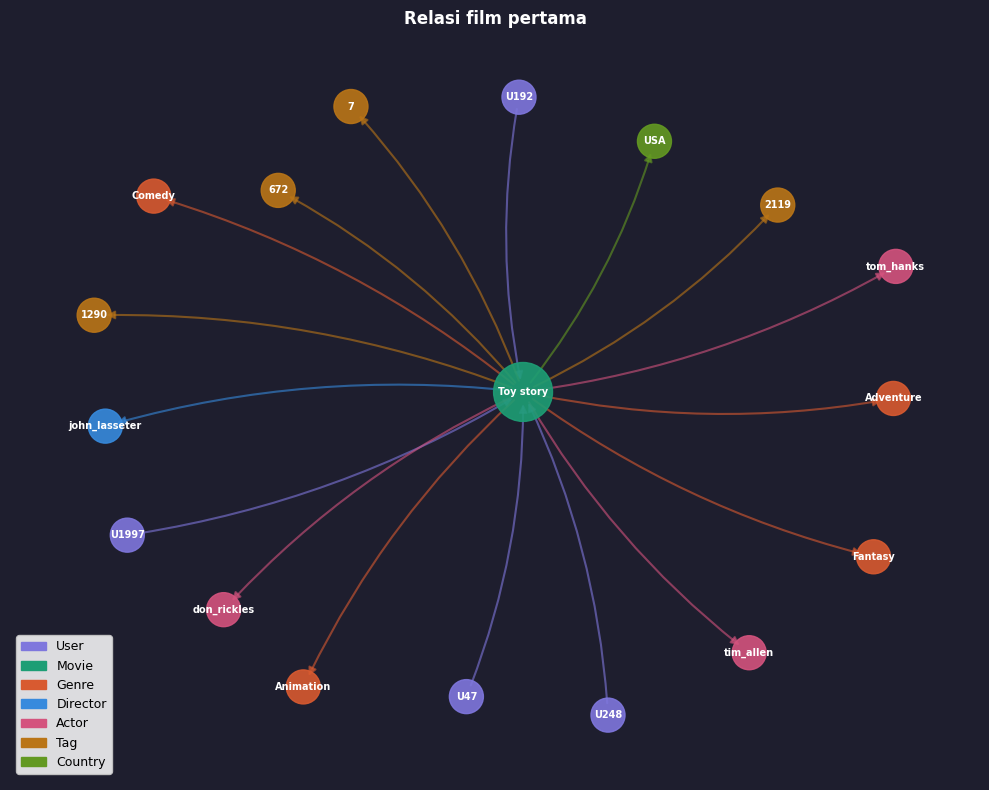

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')
ax.set_title('Relasi film pertama', fontweight='bold', color='white')

def get_label(n):
    etype = get_entity_type(n)
    if etype == 'User':     return f'U{n}'
    if etype == 'Movie':
        rev = {v:k for k,v in movie_map.items()}
        raw = rev.get(n - OFFSET_MOVIE)
        t   = df_movies[df_movies[df_movies.columns[0]]==raw][df_movies.columns[1]].values
        return t[0][:15] if len(t) else 'Movie'
    if etype == 'Director': return {v:k for k,v in director_map.items()}.get(n-OFFSET_DIR, 'Dir')
    if etype == 'Actor':    return {v:k for k,v in actor_map.items()}.get(n-OFFSET_ACTOR, 'Actor')
    if etype == 'Genre':    return {v:k for k,v in genre_map.items()}.get(n-OFFSET_GENRE, 'Genre')
    if etype == 'Tag':      return {v:k for k,v in tag_map.items()}.get(n-OFFSET_TAG, 'Tag')
    if etype == 'Country':  return {v:k for k,v in country_map.items()}.get(n-OFFSET_COUNTRY, 'Country')

pos2       = nx.spring_layout(SG, seed=42, k=2.5)
node_colors = [ENTITY_COLORS.get(get_entity_type(n), '#aaa') for n in SG.nodes()]
node_sizes  = [1800 if n==center else 600 for n in SG.nodes()]

nx.draw_networkx_nodes(SG, pos2, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(SG, pos2, ax=ax, labels={n: get_label(n) for n in SG.nodes()},
                        font_size=7, font_color='white', font_weight='bold')
nx.draw_networkx_edges(SG, pos2, ax=ax, arrows=True, arrowsize=12,
                       edge_color=[REL_COLORS.get(rel_names.get(d.get('r',-1),''),'#aaa')
                                   for _,_,d in SG.edges(data=True)],
                       width=1.5, alpha=0.6, connectionstyle='arc3,rad=0.1')

ax.legend(handles=[mpatches.Patch(color=c, label=t) for t,c in ENTITY_COLORS.items()],
          fontsize=9, loc='lower left', framealpha=0.85)
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [14]:
# Tensor KG untuk model
_h, _r, _t = zip(*triplets)
KG_H = torch.LongTensor(_h)
KG_R = torch.LongTensor(_r)
KG_T = torch.LongTensor(_t)

def build_user_items(df):
    df2 = df[df['userID'].isin(user_map) & df['movieID'].isin(movie_map)].copy()
    df2['u_enc'] = df2['userID'].map(user_map)
    df2['m_enc'] = df2['movieID'].map(movie_map)
    return df2.groupby('u_enc')['m_enc'].apply(set).to_dict()

train_ui = build_user_items(df_train)
val_ui   = build_user_items(df_val)
test_ui  = build_user_items(df_test)

print(f'KG tensor size : {len(KG_H):,} edges')
print(f'Avg film/user  : {np.mean([len(v) for v in train_ui.values()]):.1f}')

class KGDataset(Dataset):
    def __init__(self, triplets_arr, n_ent, seed=42):
        self.T   = torch.LongTensor(triplets_arr)
        self.n   = n_ent
        self.rng = np.random.default_rng(seed)

    def __len__(self): return len(self.T)

    def __getitem__(self, i):
        h, r, t = self.T[i]
        if self.rng.random() < 0.5:
            hn = int(self.rng.integers(0, self.n))
            return h, r, t, torch.tensor(hn), t
        tn = int(self.rng.integers(0, self.n))
        return h, r, t, h, torch.tensor(tn)

class BPRDataset(Dataset):
    def __init__(self, user_items, n_items, seed=42):
        self.ui   = user_items
        self.n    = n_items
        self.data = [(u, i) for u, items in user_items.items() for i in items]
        self.rng  = np.random.default_rng(seed)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        u, ip = self.data[idx]
        pos   = self.ui[u]
        ineg  = int(self.rng.integers(0, self.n))
        while ineg in pos:
            ineg = int(self.rng.integers(0, self.n))
        return torch.LongTensor([u, ip, ineg])

train_loader = DataLoader(
    BPRDataset(train_ui, N_MOVIE, seed=SEED),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f'BPR samples    : {len(train_loader.dataset):,}')
print(f'Steps/epoch    : {len(train_loader):,}')

KG tensor size : 1,056,206 edges
Avg film/user  : 198.5
BPR samples    : 418,800
Steps/epoch    : 409


## 7. KG Embedding — TransR Pre-training

In [15]:
class TransR(nn.Module):
    def __init__(self, n_ent, n_rel, dim, margin=1.0):
        super().__init__()
        self.dim    = dim
        self.margin = margin
        self.ent    = nn.Embedding(n_ent, dim)
        self.rel    = nn.Embedding(n_rel, dim)
        self.M      = nn.Embedding(n_rel, dim * dim)
        nn.init.xavier_uniform_(self.ent.weight)
        nn.init.xavier_uniform_(self.rel.weight)
        with torch.no_grad():
            for i in range(n_rel):
                self.M.weight[i] = torch.eye(dim).flatten()

    def _proj(self, e, r):
        M = self.M(r).view(-1, self.dim, self.dim)
        return torch.bmm(M, e.unsqueeze(-1)).squeeze(-1)

    def _score(self, h, r, t):
        eh = F.normalize(self.ent(h), p=2, dim=-1)
        et = F.normalize(self.ent(t), p=2, dim=-1)
        return torch.norm(self._proj(eh, r) + self.rel(r) - self._proj(et, r), p=2, dim=-1)

    def forward(self, h, r, t, hn, tn):
        return F.relu(self.margin + self._score(h, r, t) - self._score(hn, r, tn)).mean()

  Epoch  20/100  Loss: 0.0472
  Epoch  40/100  Loss: 0.0407
  Epoch  60/100  Loss: 0.0371
  Epoch  80/100  Loss: 0.0348
  Epoch 100/100  Loss: 0.0341
Embedding disimpan: entity_emb.pt, relation_emb.pt


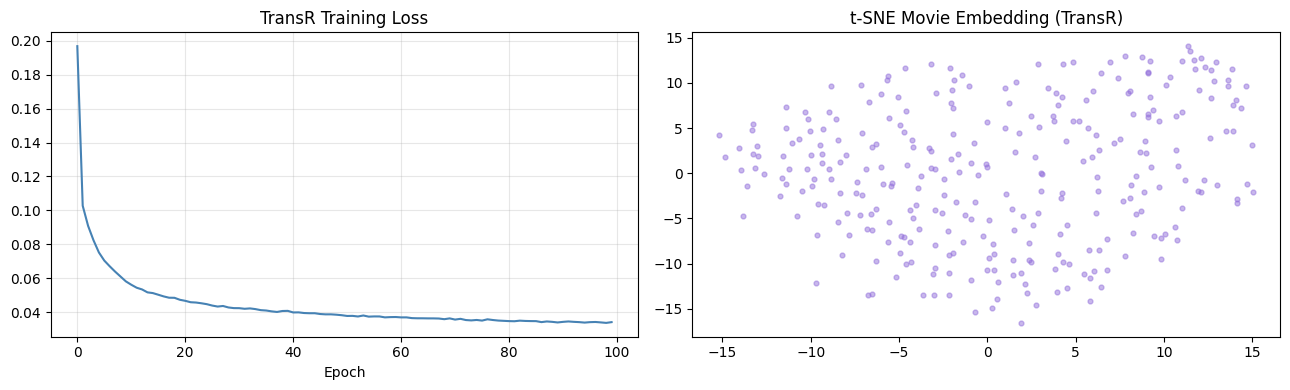

In [16]:
kg_loader = DataLoader(
    KGDataset(np.array(triplets), N_ENTITY, seed=SEED),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

transr   = TransR(N_ENTITY, N_REL_TOTAL, EMBED_DIM).to(DEVICE)
opt_tr   = torch.optim.Adam(transr.parameters(), lr=1e-3)
tr_losses = []

for ep in range(1, TRANSR_EPOCHS + 1):
    transr.train()
    total_loss = 0.0
    for h, r, t, hn, tn in kg_loader:
        h, r, t, hn, tn = [x.to(DEVICE) for x in (h, r, t, hn, tn)]
        opt_tr.zero_grad()
        loss = transr(h, r, t, hn, tn)
        loss.backward()
        opt_tr.step()
        total_loss += loss.item()
    avg = total_loss / len(kg_loader)
    tr_losses.append(avg)
    if ep % 20 == 0:
        print(f'  Epoch {ep:>3}/{TRANSR_EPOCHS}  Loss: {avg:.4f}')

torch.save(transr.ent.weight.data.cpu(), 'entity_emb.pt')
torch.save(transr.rel.weight.data.cpu(), 'relation_emb.pt')
print('Embedding disimpan: entity_emb.pt, relation_emb.pt')

# Plot TransR loss + t-SNE
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(tr_losses, color='steelblue')
axes[0].set_title('TransR Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

embs = transr.ent.weight[OFFSET_MOVIE:OFFSET_MOVIE + min(300, N_MOVIE)].detach().cpu().numpy()
xy   = TSNE(2, random_state=SEED, perplexity=30).fit_transform(embs)
axes[1].scatter(xy[:, 0], xy[:, 1], s=12, alpha=0.5, c='mediumpurple')
axes[1].set_title('t-SNE Movie Embedding (TransR)')

plt.tight_layout()
plt.show()

## 8. Model KGAT

In [17]:
class KGAT(nn.Module):
    def __init__(self, n_ent, n_rel, dim, n_layers, dropout,
                 kg_h, kg_r, kg_t,
                 offset_user, offset_movie, n_user, n_movie,
                 pre_ent=None, pre_rel=None):
        super().__init__()
        self.dim          = dim
        self.n_layers     = n_layers
        self.n_ent        = n_ent
        self.offset_user  = offset_user
        self.offset_movie = offset_movie
        self.n_user       = n_user
        self.n_movie      = n_movie

        self.register_buffer('kg_h', kg_h)
        self.register_buffer('kg_r', kg_r)
        self.register_buffer('kg_t', kg_t)

        self.ent_emb = nn.Embedding(n_ent, dim)
        self.rel_emb = nn.Embedding(n_rel, dim)
        if pre_ent is not None: self.ent_emb.weight.data.copy_(pre_ent)
        else: nn.init.xavier_uniform_(self.ent_emb.weight)
        if pre_rel is not None: self.rel_emb.weight.data.copy_(pre_rel)
        else: nn.init.xavier_uniform_(self.rel_emb.weight)

        self.attn = nn.ModuleList([
            nn.Linear(dim * 3, 1, bias=False) for _ in range(n_layers)
        ])
        self.drop = nn.Dropout(dropout)

    def propagate(self):
        all_embs = [self.ent_emb.weight]
        cur      = self.ent_emb.weight
        h_b, r_b, t_b = self.kg_h, self.kg_r, self.kg_t

        for layer_idx in range(self.n_layers):
            eh  = cur[h_b]
            er  = self.rel_emb(r_b)
            et  = cur[t_b]

            raw = self.attn[layer_idx](torch.cat([eh, er, et], dim=-1)).squeeze(-1)
            raw = raw - raw.max()

            exp_raw = torch.exp(raw)
            denom   = torch.zeros(self.n_ent, device=cur.device)
            denom.index_add_(0, h_b, exp_raw)
            attn_w  = exp_raw / denom[h_b].clamp(min=1e-8)

            new_emb = torch.zeros_like(cur)
            new_emb.index_add_(0, h_b, attn_w.unsqueeze(-1) * et)

            cur = F.normalize(new_emb + self.ent_emb.weight, p=2, dim=-1)
            cur = self.drop(cur)
            all_embs.append(cur)

        return torch.cat(all_embs, dim=-1)

    def get_scores(self, u_ids):
        E  = self.propagate()
        eu = E[u_ids + self.offset_user]
        ei = E[self.offset_movie:self.offset_movie + self.n_movie]
        return torch.matmul(eu, ei.T)
print('KGAT class siap')

KGAT class siap


In [18]:
pre_ent = (torch.load('entity_emb.pt')
           if os.path.exists('entity_emb.pt') else None)
pre_rel = (torch.load('relation_emb.pt')
           if os.path.exists('relation_emb.pt') else None)

model = KGAT(
    n_ent=N_ENTITY, n_rel=N_REL_TOTAL, dim=EMBED_DIM,
    n_layers=N_LAYERS, dropout=DROPOUT,
    kg_h=KG_H, kg_r=KG_R, kg_t=KG_T,
    offset_user=OFFSET_USER, offset_movie=OFFSET_MOVIE,
    n_user=N_USER,           n_movie=N_MOVIE,
    pre_ent=pre_ent, pre_rel=pre_rel,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameter    : {n_params:,}')
print(f'Dim={EMBED_DIM} | Layers={N_LAYERS} | Dropout={DROPOUT}')
print(f'LR={LR} | WeightDecay={WEIGHT_DECAY} | RegWeight={REG_WEIGHT}')
print(f'Pretrained   : {pre_ent is not None}')

Parameter    : 1,883,584
Dim=64 | Layers=3 | Dropout=0.3
LR=0.001 | WeightDecay=1e-05 | RegWeight=0.0001
Pretrained   : True


## 9. Fungsi Evaluasi

In [19]:
def evaluate(model, ui_test, ui_train, K_list, device, n_neg=99):
    model.eval()
    res = {f'{m}@{k}': [] for m in ['P', 'R', 'NDCG', 'HR'] for k in K_list}
    rng = np.random.default_rng(SEED)

    with torch.no_grad():
        E = model.propagate()

        u_emb_all = E[model.offset_user:
                      model.offset_user + model.n_user].cpu().numpy()
        i_emb_all = E[model.offset_movie:
                      model.offset_movie + model.n_movie].cpu().numpy()

        all_scores = u_emb_all @ i_emb_all.T

        for u, pos_set in ui_test.items():
            if not pos_set:
                continue

            seen      = ui_train.get(u, set())
            scores_u  = all_scores[u]
            pos_list  = list(pos_set)
            n_pos     = len(pos_list)

            excluded_base = np.array(list(seen), dtype=np.int64)
            excluded_base = excluded_base[excluded_base < model.n_movie]

            for k in K_list:
                prec_l, rec_l, hr_l, ndcg_l = [], [], [], []

                for pos_item in pos_list:
                    mask = np.ones(model.n_movie, dtype=bool)
                    mask[excluded_base] = False
                    for pi in pos_list:
                        if pi != pos_item and pi < model.n_movie:
                            mask[pi] = False

                    cands = np.where(mask)[0]
                    size  = min(n_neg, len(cands))
                    negs  = rng.choice(cands, size=size, replace=False)

                    items  = np.concatenate([[pos_item], negs])
                    s      = scores_u[items]
                    rank   = int(np.where(np.argsort(-s) == 0)[0][0]) + 1
                    hit    = 1 if rank <= k else 0

                    prec_l.append(hit / k)
                    rec_l.append(hit / n_pos)
                    hr_l.append(float(hit))
                    ndcg_l.append(1 / np.log2(rank + 1) if rank <= k else 0.0)

                res[f'P@{k}'].append(np.mean(prec_l))
                res[f'R@{k}'].append(np.mean(rec_l))
                res[f'HR@{k}'].append(np.mean(hr_l))
                res[f'NDCG@{k}'].append(np.mean(ndcg_l))

    return {k: float(np.mean(v)) for k, v in res.items()}

print('Fungsi evaluate siap')

Fungsi evaluate siap


## 10. Training KGAT

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCH, eta_min=1e-5)

best_recall, patience_cnt = 0.0, 0
train_losses, val_history = [], []

print(f'Training KGAT | max {MAX_EPOCH} epoch | patience={PATIENCE} eval-cycles')
print(f'LR={LR} | Dropout={DROPOUT} | RegWeight={REG_WEIGHT}')
print('=' * 60)

for epoch in range(1, MAX_EPOCH + 1):
    model.train()
    epoch_total = 0.0
    for batch in train_loader:
        u    = batch[:, 0].to(DEVICE)
        ip   = batch[:, 1].to(DEVICE)
        ineg = batch[:, 2].to(DEVICE)

        optimizer.zero_grad()
        E  = model.propagate()

        eu = E[u    + model.offset_user]
        ei = E[ip   + model.offset_movie]
        en = E[ineg + model.offset_movie]

        bpr  = -F.logsigmoid((eu * ei).sum(-1) - (eu * en).sum(-1)).mean()
        reg  = (eu.norm(2).pow(2) + ei.norm(2).pow(2) + en.norm(2).pow(2)) / len(u)
        loss = bpr + REG_WEIGHT * reg

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_total += loss.item()

    avg = epoch_total / len(train_loader)
    train_losses.append(avg)
    scheduler.step()

    # Evaluasi setiap 5 epoch
    if epoch % 5 == 0:
        vm  = evaluate(model, val_ui, train_ui, K_LIST, DEVICE)
        val_history.append((epoch, vm))
        r20 = vm['R@20']
        print(f'  Ep {epoch:>3} | Loss: {avg:.4f} | R@20: {r20:.4f} | NDCG@20: {vm["NDCG@20"]:.4f}')
        if r20 > best_recall:
            best_recall = r20
            torch.save(model.state_dict(), 'kgat_best.pt')
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping di epoch {epoch}')
            break

print(f'\nSelesai | Best Recall@20: {best_recall:.4f} | Disimpan: kgat_best.pt')

Training KGAT | max 100 epoch | patience=10 eval-cycles
LR=0.001 | Dropout=0.3 | RegWeight=0.0001
  Ep   5 | Loss: 0.1323 | R@20: 0.1293 | NDCG@20: 0.4900
  Ep  10 | Loss: 0.1326 | R@20: 0.1292 | NDCG@20: 0.4898
  Ep  15 | Loss: 0.1351 | R@20: 0.1303 | NDCG@20: 0.4904
  Ep  20 | Loss: 0.1359 | R@20: 0.1301 | NDCG@20: 0.4901
  Ep  25 | Loss: 0.1365 | R@20: 0.1303 | NDCG@20: 0.4905
  Ep  30 | Loss: 0.1369 | R@20: 0.1293 | NDCG@20: 0.4891
  Ep  35 | Loss: 0.1366 | R@20: 0.1295 | NDCG@20: 0.4896
  Ep  40 | Loss: 0.1368 | R@20: 0.1296 | NDCG@20: 0.4907
  Ep  45 | Loss: 0.1365 | R@20: 0.1289 | NDCG@20: 0.4903
  Ep  50 | Loss: 0.1366 | R@20: 0.1303 | NDCG@20: 0.4908
  Ep  55 | Loss: 0.1354 | R@20: 0.1291 | NDCG@20: 0.4910
  Ep  60 | Loss: 0.1355 | R@20: 0.1306 | NDCG@20: 0.4918
  Ep  65 | Loss: 0.1353 | R@20: 0.1297 | NDCG@20: 0.4918
  Ep  70 | Loss: 0.1338 | R@20: 0.1304 | NDCG@20: 0.4932
  Ep  75 | Loss: 0.1341 | R@20: 0.1297 | NDCG@20: 0.4926
  Ep  80 | Loss: 0.1335 | R@20: 0.1307 | NDCG@2

## 11. Evaluasi Final

In [21]:
model.load_state_dict(torch.load('kgat_best.pt', map_location=DEVICE))
test_m = evaluate(model, test_ui, train_ui, K_LIST, DEVICE)

rows = [{'K': k,
         'Precision': test_m[f'P@{k}'],
         'Recall':    test_m[f'R@{k}'],
         'NDCG':      test_m[f'NDCG@{k}'],
         'HR':        test_m[f'HR@{k}']}
        for k in K_LIST]

df_res = pd.DataFrame(rows).set_index('K').round(4)
df_res.to_csv('kgat_results.csv')
print('HASIL EVALUASI KGAT — TEST SET')
display(df_res)

HASIL EVALUASI KGAT — TEST SET


,Precision,Recall,NDCG,HR
K,,,,
5,0.0957,0.0587,0.3357,0.4787
10,0.0637,0.0755,0.3860,0.6367
20,0.0392,0.0879,0.4228,0.7841


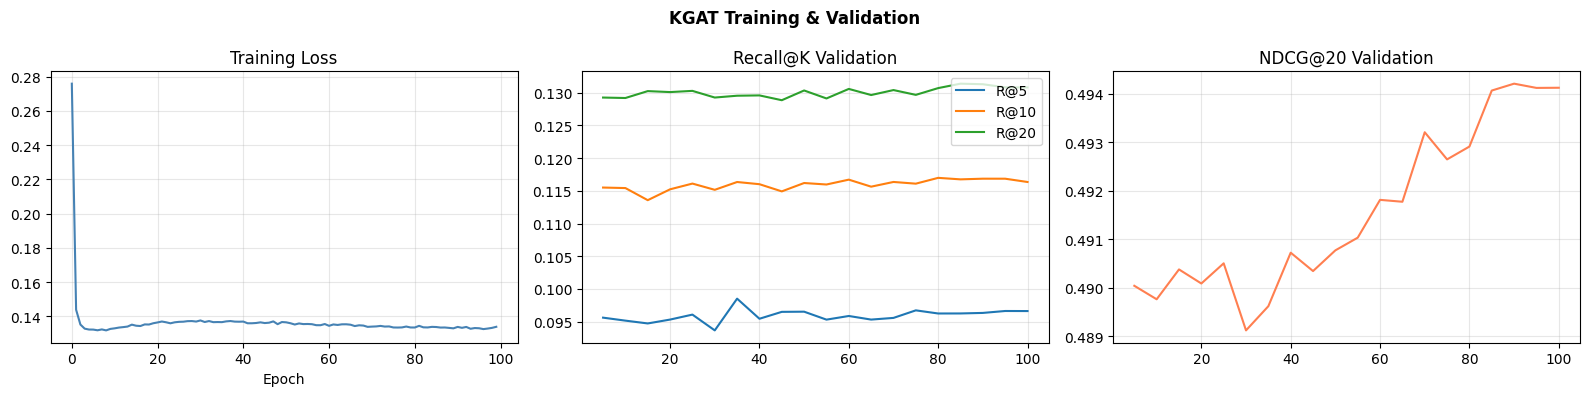

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('KGAT Training & Validation', fontweight='bold')
axes[0].plot(train_losses, color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

if val_history:
    ep_list = [e for e, _ in val_history]
    for k in K_LIST:
        axes[1].plot(ep_list, [m[f'R@{k}'] for _, m in val_history], label=f'R@{k}')
    axes[1].set_title('Recall@K Validation')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(ep_list, [m['NDCG@20'] for _, m in val_history], color='coral')
    axes[2].set_title('NDCG@20 Validation')
    axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Contoh Rekomendasi

In [23]:
rev_movie = {v: k for k, v in movie_map.items()}
rev_user  = {v: k for k, v in user_map.items()}
mid_col   = 'id'    if 'id'    in df_movies.columns else df_movies.columns[0]
ttl_col   = 'title' if 'title' in df_movies.columns else df_movies.columns[1]
title_d   = dict(zip(df_movies[mid_col], df_movies[ttl_col]))

model.eval()
sample_users = list(test_ui.keys())[:3]

with torch.no_grad():
    E         = model.propagate()
    i_emb_all = E[model.offset_movie:model.offset_movie + model.n_movie].cpu().numpy()

    for ue in sample_users:
        u_vec  = E[ue + model.offset_user].cpu().numpy()
        scores = i_emb_all @ u_vec
        seen   = train_ui[ue] | val_ui.get(ue, set())
        scores[list(seen)] = -np.inf
        top10  = np.argsort(-scores)[:10]

        print(f'\nUser {rev_user.get(ue, ue)} (enc={ue})')
        liked = [title_d.get(rev_movie.get(m, m), str(m))
                 for m in list(train_ui[ue])[:3]]
        print(f'  Disukai (train) : {", ".join(liked)}')
        print('  Top-10 Rekomendasi:')
        for rank, me in enumerate(top10, 1):
            print(f'    {rank:>2}. {title_d.get(rev_movie.get(me, me), str(me))}')


User 75 (enc=0)
  Disukai (train) : Last Man Standing, Desperado, Die Hard: With a Vengeance
  Top-10 Rekomendasi:
     1. The Rock
     2. Predator
     3. 1668
     4. X-Men
     5. The Matrix
     6. Equilibrium
     7. Ronin
     8. Terminator Salvation
     9. Gladiator
    10. The Matrix Reloaded

User 78 (enc=1)
  Disukai (train) : The Long Good Friday, The Flim-Flam Man, War of the Worlds
  Top-10 Rekomendasi:
     1. The Usual Suspects
     2. Star Wars: Episode V - The Empire Strikes Back
     3. MASH
     4. Star Wars
     5. Groundhog Day
     6. Taxi Driver
     7. The Lord of the Rings: The Fellowship of the Ring
     8. The Crying Game
     9. The Meaning of Life
    10. Wo hu cang long

User 127 (enc=2)
  Disukai (train) : 13 Going on 30, The Hills Have Eyes II, The Fog
  Top-10 Rekomendasi:
     1. Saw II
     2. Saw III
     3. Click
     4. Hostel
     5. Final Destination 3
     6. Snakes on a Plane
     7. The Holiday
     8. The Ring Two
     9. Spider-Man 3
    